In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv(r'C:\Users\Gleb\Desktop\Итмо\Основы Питона\train.csv').sort_values(by = 'Age', ascending = False)
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
456,457,0,1,"Millet, Mr. Francis Davis",male,65.0,0,0,13509,26.5500,E38,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C


**Визуализируйте распределение значений признаков Survived, Pclass, Age, Sex, Parch**

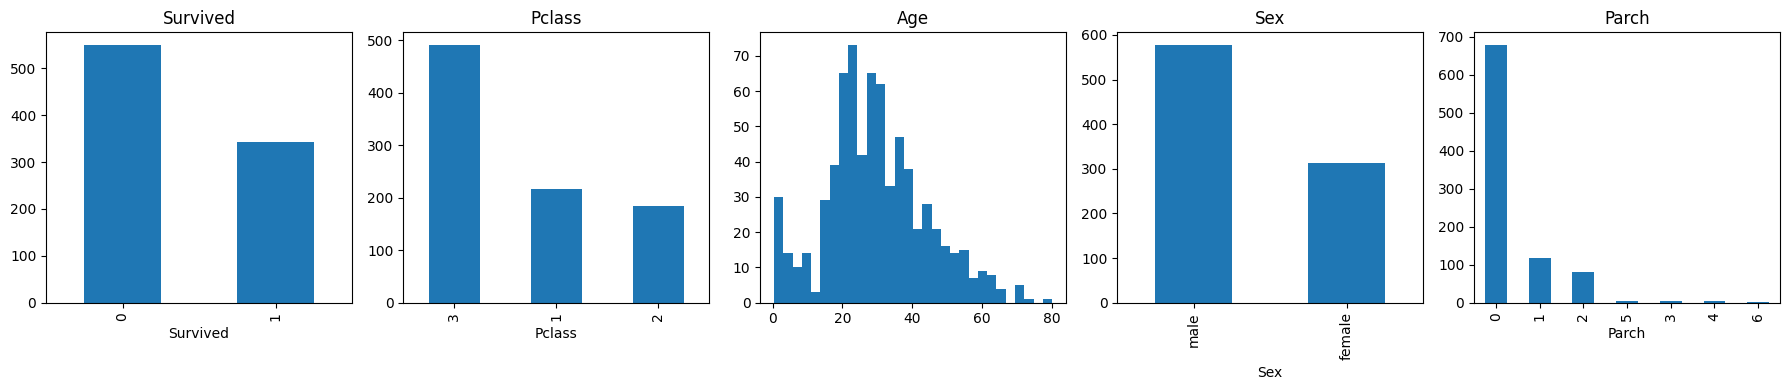

In [2]:
fig, axes = plt.subplots(1,5, figsize=(18,4))

df['Survived'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Survived')

df['Pclass'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Pclass')

axes[2].hist(df['Age'].dropna(), bins=30)
axes[2].set_title('Age')

df['Sex'].value_counts().plot(kind='bar', ax=axes[3])
axes[3].set_title('Sex')

df['Parch'].value_counts().plot(kind='bar', ax=axes[4])
axes[4].set_title('Parch')

plt.tight_layout()
plt.show()

**boxplot для столбца Age**

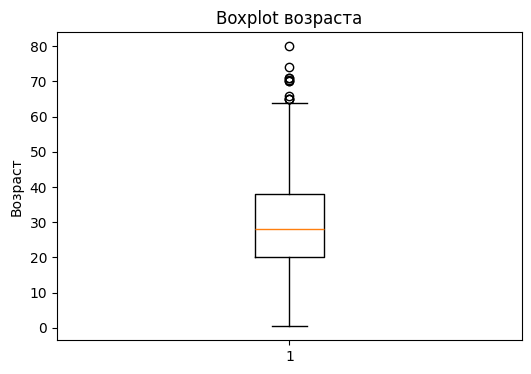

In [3]:
plt.figure(figsize=(6,4))

plt.boxplot(df['Age'].dropna())

plt.title('Boxplot возраста')
plt.ylabel('Возраст')

plt.show()

**Проинтерпретируйте полученный график**

In [4]:
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
median_age = df['Age'].median()

print(f'Медианный возраст пассажиров: {median_age:.1f} лет.')
print(f'Основной диапазон (межквартильный): {q1:.1f}–{q3:.1f} лет.')
print('На графике также наблюдаются выбросы среди пассажиров старшего возраста.')

Медианный возраст пассажиров: 28.0 лет.
Основной диапазон (межквартильный): 20.1–38.0 лет.
На графике также наблюдаются выбросы среди пассажиров старшего возраста.


**Постройте график типа pie chart**

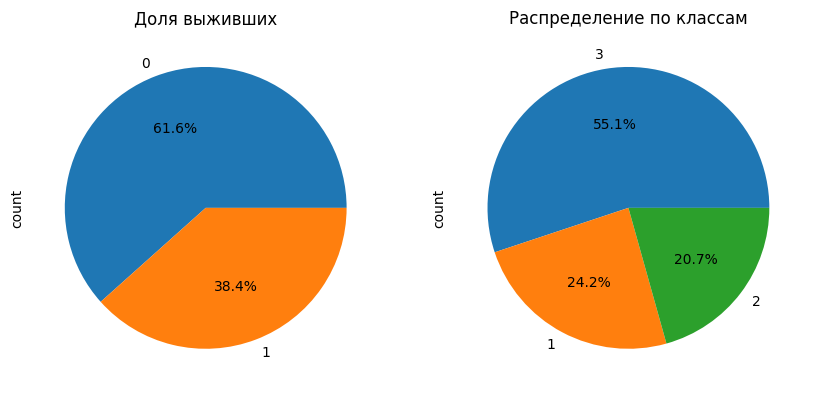

In [5]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

df['Survived'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0]
)
axes[0].set_title('Доля выживших')

df['Pclass'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1]
)
axes[1].set_title('Распределение по классам')

plt.show()

**Постройте график типа pairplot**

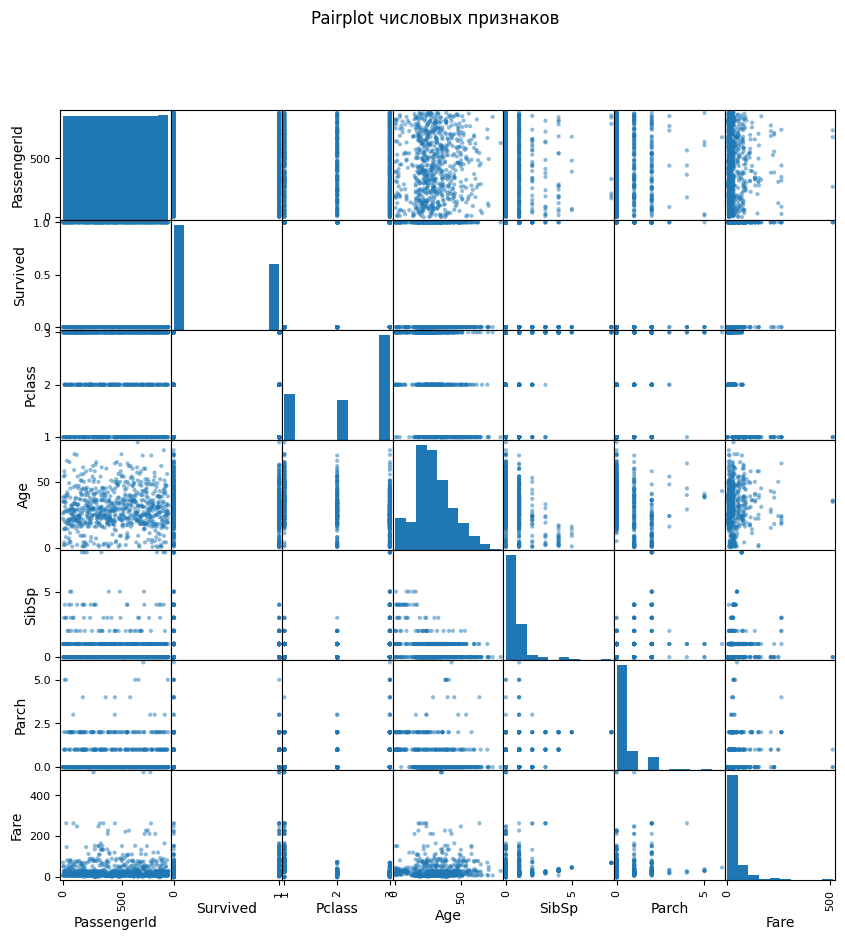

In [6]:
pd.plotting.scatter_matrix(
    df.select_dtypes(include='number'),
    figsize=(10,10)
)

plt.suptitle('Pairplot числовых признаков')
plt.show()

**Постройте violin plot**

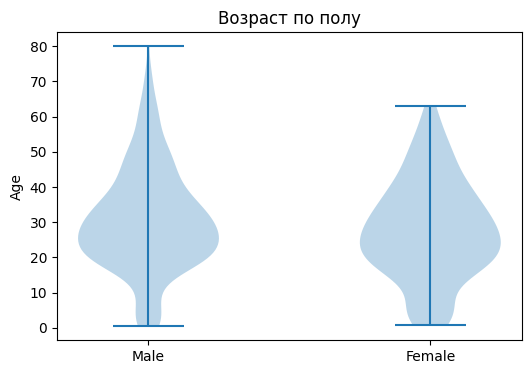

In [7]:
data = [
    df[df['Sex']=='male']['Age'].dropna(),
    df[df['Sex']=='female']['Age'].dropna()
]

plt.figure(figsize=(6,4))

plt.violinplot(data)

plt.xticks([1,2], ['Male','Female'])
plt.title('Возраст по полу')
plt.ylabel('Age')

plt.show()

**Постройте heatmap**

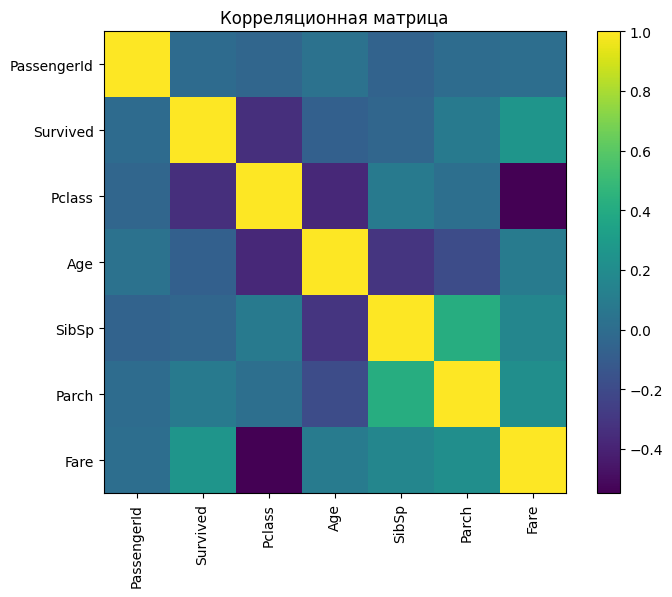

In [8]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)

plt.title('Корреляционная матрица')

plt.show()

**Постройте интерактивный sunburst plot**

In [9]:
pio.renderers.default = "notebook"

sunburst_data = df.groupby(['Pclass','Sex']).size().reset_index(name='count')

fig = px.sunburst(
    sunburst_data,
    path=['Pclass','Sex'],
    values='count',
    title='Структура пассажиров по классу и полу'
)

fig.show()